텍스트 전처리

- 비정형 텍스트 정규표현식 정리
- 데이터 정제후 전후 비교
- 뉴스(격식체), 실제 리뷰(구어체), 어떻게 다른 지 확인
- 정제 과정을 - > 함수로 만들어 사용

- 뉴스.csv -> 네이버 뉴스 1000건 - 경제 IT 과학 등
- 제주관광공사 비짓 리뷰 5917건 공공데이터포털 - encondig=cp949

- 비정형 텍스트 데이터 :
    - 공백 다수 존재
    - 특수 문자 다수 존재
    - 언론사명, 링크, 이메일 -> 내용 자체에 중요도는 낮다
- 리뷰데이터 특성 :
    - 감탄사
    - 붙여쓰기
    - 이모지
    - 반복 문자 -> ㅋㅋㅋ, ㅎㅎㅎ,



### 뉴스 데이터
- 정제시작

In [19]:
import pandas as pd

df = pd.read_csv("../data/11-1_뉴스원본.csv")


In [20]:
df[['제목','본문']].head(3)

,제목,본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...


### 2. 정규 표현식
- "~ 이런 문자를 찾아라"를 적는 규칙
- 숫자로 시작하는 단어나, http로 시작하는 링크와 같은 패턴을 기호로 적는 방법
- re.sub(찾을규치, 바꿀 것, 텍스트) -> 원하는 부분 찾아 변경
- \s : 공백이 아닌 글자
- [^...] : 이것들이 아닌 것


In [21]:
import re

sample = '행사 안내입니다 http://events.com/2026 참고하세요'

result = re.sub(r'https?://\S+', '', sample)

print("치환한 결과 :", result.strip())

치환한 결과 : 행사 안내입니다  참고하세요


In [22]:
### 2.경우 2

sample = '문의는 http://events.com/2026 으로 주세요'

result = re.sub(r'https?://\S+@\S', '',sample)

print("치환한 결과 :", result.strip())


치환한 결과 : 문의는 http://events.com/2026 으로 주세요


#### 3. 경우3
- 특수 문자를 지우고 싶을 때


In [23]:
sample = "삼성전자 주가 20% 상승 (역대 최고 상승)" 

result = re.sub(r'[^가-힣a-zA-z\s]', '',sample) # ^괄호 안에 적은 것을 제외한 문자

print("정제후", result)

정제후 삼성전자 주가  상승 역대 최고 상승


###4. 경우4
- 공백이 많은 경우 -> 특수문자를 지우면 공백이 생성되어 -> 하나이상으로 공백을 하나로 변경


In [24]:
sample = "정제후 삼성전자 주가  상승 역대 최고 상승"
result = re.sub(r"\s+"," ",sample)

print(result)

정제후 삼성전자 주가 상승 역대 최고 상승


In [25]:
# 번외 숫자 없애기
smple = "정제후 삼성전자 주가 20 상승 역대 최고 상승"

result = re.sub(r"[0-9]+","",sample)
print(result)

정제후 삼성전자 주가  상승 역대 최고 상승


### 3. 정규화 
- 정제 -> 불필요한 것 지우기
- 정규화 -> 같은 의미이나 다르게 적힌 표기를 하나로 통일
-예)
 - Apple,apple -> 같은 단어
 - 대소문자 통일, 공백, 반복자 정리
 - 유니코드 정규화

### 4. 경우를 묶어서 한꺼번에 처리하는 함수 만들기
- 정제함수 만들기
    - URL 제거
    - 이메일 제거
    - 특수문자 제거
    - 공백처리

In [26]:
def clean_news_title(text):
      # 1. URL 제거
      text = re.sub(r"https?://\S+", " ", text)

      # 2. 이메일 제거
      text = re.sub(r"\S+@\S+", " ", text)

      # 3. 특수문자 제거
      # 한글, 영어, 숫자, 공백만 남깁니다.
      text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

      # 4. 여러 공백을 한 칸으로 바꾸고, 앞뒤 공백 제거
      text = re.sub(r"\s+", " ", text).strip()

      return text

In [27]:
df.head(1)
df['본문'][3]

'img tag s 지난 30일 서울의 한 주유소. 〈사진 연합뉴스〉 img tag e 오늘 1일 부터 유류세율 인하 폭이 확대됩니다. 올해 3분기에는 생애최초 주택 구매 대출 규제도 완화됩니다. 기획재정부에 따르면 정부는 계속되는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 최대한도인 37%로 인하합니다. img tag s 〈사진 기획재정부〉 img tag e 기존 30%에서 대통령령으로 가능한 최대폭까지 확대한 겁니다. 이에 따라 휘발유는 리터당 57원 경유는 38원 LPG는 12원 싸집니다. img tag s 〈사진 기획재정부〉 img tag e 또 오는 10월부터는 코로나19 피해로 대출상환에 어려움을 겪는 소상공인과 자영업자를 위한 채무조정 프로그램도 시행합니다. 최대 30조원 규모로 소상공인·자영업자 새출발기금 가칭 을 설립해 대출채권 매입 등의 방식으로 상환일정 조정과 채무감면을 지원할 계획입니다. img tag s 〈사진 기획재정부〉 img tag e 부동산 대출 규제도 완화합니다. 생애 최초 주택 구매자에 대해서는 LTV 상한을 주택 소재 지역이나 가격 소득과 상관없이 80%로 완화합니다. 올해 3분기 중에 시행할 계획입니다. 지금은 투기과열지구 경우 LTV가 60%까지 조정대상지역은 70%까지 적용되고 있습니다. 이외에 올해 하반기에 바뀌는 정책은 기획재정부 홈페이지와 지자체 공공기관 등에서 확인할 수 있습니다.'

In [28]:
result = clean_news_title(df['본문'][3])
print(result)

img tag s 지난 30일 서울의 한 주유소 사진 연합뉴스 img tag e 오늘 1일 부터 유류세율 인하 폭이 확대됩니다 올해 3분기에는 생애최초 주택 구매 대출 규제도 완화됩니다 기획재정부에 따르면 정부는 계속되는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 최대한도인 37 로 인하합니다 img tag s 사진 기획재정부 img tag e 기존 30 에서 대통령령으로 가능한 최대폭까지 확대한 겁니다 이에 따라 휘발유는 리터당 57원 경유는 38원 LPG는 12원 싸집니다 img tag s 사진 기획재정부 img tag e 또 오는 10월부터는 코로나19 피해로 대출상환에 어려움을 겪는 소상공인과 자영업자를 위한 채무조정 프로그램도 시행합니다 최대 30조원 규모로 소상공인 자영업자 새출발기금 가칭 을 설립해 대출채권 매입 등의 방식으로 상환일정 조정과 채무감면을 지원할 계획입니다 img tag s 사진 기획재정부 img tag e 부동산 대출 규제도 완화합니다 생애 최초 주택 구매자에 대해서는 LTV 상한을 주택 소재 지역이나 가격 소득과 상관없이 80 로 완화합니다 올해 3분기 중에 시행할 계획입니다 지금은 투기과열지구 경우 LTV가 60 까지 조정대상지역은 70 까지 적용되고 있습니다 이외에 올해 하반기에 바뀌는 정책은 기획재정부 홈페이지와 지자체 공공기관 등에서 확인할 수 있습니다


In [29]:
df['정제본문'] = df['본문'].apply(clean_news_title)
df.head(3)

,제목,본문,카테고리,요약,출처URL,정제본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import scipy.stats as stats

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [31]:
df['본문'].str.len()

0        62
1       941
2       426
3       714
4       920
       ... 
995    1187
996    1430
997    3574
998    1679
999    1492
Name: 본문, Length: 1000, dtype: int64

In [32]:
df['정제본문'].str.len()

0        61
1       932
2       404
3       693
4       906
       ... 
995    1174
996    1382
997    3504
998    1637
999    1470
Name: 정제본문, Length: 1000, dtype: int64

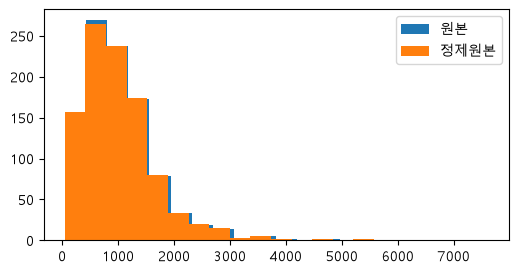

In [33]:
plt.figure(figsize=(6,3))
plt.hist(df['본문'].str.len(), bins=20,label='원본')
plt.hist(df['정제본문'].str.len(), bins=20,label='정제원본')
plt.legend()
plt.show()

5. 실전 비짓 제주 데이터 사용

In [34]:
import re # 정규표현식을 사용하는 모듈
jeju = pd.read_csv("../data/11-1_visitjeju_reviews.csv",encoding='cp949')
jeju


,리뷰내용,추천수
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,159
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",132
2,메밀꽃 지평선과 하늘입니다,57
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,29
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,29
...,...,...
5912,제주를 사랑하시는 저의 아버지는 겨울왕국이 있을 것처럼 눈이 소복하게 쌓인 한라산을...,1
5913,중문 놀러왔다가 들렸어요~ 체험 할 거리도 많고 사진도 많이 찍을 수 있어서 좋았어...,1
5914,#이호테우#이호테우말등대제주도여행 마지막 날 이호테우에서 아쉬움을 달래본다.,1
5915,홀로 여행을 떠나 새로운각오을 다지고 왔어요.,1


In [35]:
def clean_review(text):
    # URL과 이메일 제거
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # 같은 문자가 3번 이상 반복되면 2번만 남김
    # 예: 예뻐요ㅠㅠㅠㅠ → 예뻐요ㅠㅠ
    # 예: 좋아요ㅋㅋㅋㅋ → 좋아요ㅋㅋ
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # 한글, 영어, 숫자, 공백, ㅋ·ㅎ·ㅠ·ㅜ만 남    김
    # 리뷰 감정 표현인 ㅋㅋ, ㅎㅎ, ㅠㅠ는 남겨둡니다.
    text = re.sub(r"[^가-힣a-zA-Z0-9\sㅋㅎㅠㅜ]", " ", text)

    # 여러 공백을 한 칸으로 정리하고 앞뒤 공백 제거
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [36]:
jeju.shape
jeju.columns
jeju.isna().sum()
# jeju.duplicated().sum()
# jeju["추천수"].describe()

리뷰내용    489
추천수       0
dtype: int64

In [37]:
jeju[jeju['리뷰내용'].str.len() <12]
jeju['리뷰내용'][0]

'제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함께 계획을 함께세우며 꼭!가자고한 장소입니다.입장권을 주고 들어오면 좌측에 제일 먼저 보이는 가랜드문구 I♡YOU. 승민,지은,수민,향유 혼자가아닌 너와함께, 우리함께여서 이 문구가 더 의미있고 기억에 남는거 같습니다.평소 표현이 서툰 제가 잊지못할 소중한 추억을 선사해준 친구들에게 제주 추억공유 캠페인을 통하여 마음을 전하고싶습니다.힘들고 지칠때 이 사진보고 힘내자 친구들아! 항상 고맙고 사랑하는거알지?ㅎㅎ 우리곁에는 항상 우리가 있다는거, 잊지마!!친구들이 볼 수있도록 좋아요 눌러주세요?사랑하는 친구들과 함께한 3박4일 #제주도여행 #성공적#제주추억공유캠페인 #추억이새록새록'

In [38]:
jeju["리뷰길이"] =jeju["리뷰내용"].fillna("").str.len() 

jeju["리뷰길이"].describe()
jeju.nlargest(10, "리뷰길이")[["리뷰내용", "리뷰길이"]]

,리뷰내용,리뷰길이
1072,안녕하세요. 최근에 스트레스를 너무 많이 받아 얼굴에 트러블이 많이 올라오고 대인기...,1000
4898,My friend and I hiked Hallasan on 17th Oct 202...,1000
1053,제주에는 유명한 명소뿐만 아니라 숨겨진 명소들도 많아 특별한 경험을 선사하는 곳이 ...,993
2056,"[정답] 2번, 2000원 / 제주시청과 제주도 남우체국, 종합청사에서 가깝게 위치...",979
1248,♣ 나는 제주에서 [한달살기] 를 하고 싶다.안녕하세요 저는 경기도 내륙에 살고 있...,963
2070,제주시 근처 점심 백반 맛집으로 굉장히 좋은 곳입니다. 노부부 두분이 운영하시는 곳...,946
1129,제주가 주는 그 특별함. 제주에 오면 매번 꼭 가는 곳이 바로 함덕해변이에요. 처음...,944
1312,"이번 여름 휴가에는 제주도에서 특별한 액티비티들을 즐겨보고 싶습니다. 제트보트, 카...",927
2243,"여름이 다가오면 마음이 설레는데, 이번 여름에는 제주도의 아름다운 중문해수욕장을 방...",925
1192,이번 여름 휴가에 제주도의 상징인 한라산을 등반해 보고싶습니다. 한라산은 대한민국에...,902


In [39]:
clean_jeju = jeju.copy()

clean_jeju["리뷰내용_정제"] = (
    clean_jeju["리뷰내용"]
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)



In [40]:
import re

def clean_review(text):
    if pd.isna(text):
        return text

    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"[\w.+-]+@[\w-]+\.[\w.-]+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()

    return text




In [41]:
clean_jeju["리뷰내용_정제"] = (
    jeju["리뷰내용"].apply(clean_review)
)

# 또는 clean_jeju에서 바로 가져와도 됩니다.

clean_jeju["리뷰내용_정제"] = (
    clean_jeju["리뷰내용"].apply(clean_review)
)

In [42]:
clean_jeju["리뷰내용_정제"] = clean_jeju["리뷰내용"].apply(clean_review)
clean_jeju["해시태그"] = clean_jeju["리뷰내용"].fillna("").str.findall(r"#\w+")

In [43]:

clean_jeju[
    clean_jeju["리뷰내용"].fillna("").str.contains(r"(.)\1{3,}", regex=True)
]

C:\Users\Lee\AppData\Local\Temp\ipykernel_4260\1749863277.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  clean_jeju["리뷰내용"].fillna("").str.contains(r"(.)\1{3,}", regex=True)


ArrowInvalid: Invalid regular expression: invalid escape sequence: \1

In [ ]:
clean_jeju["정제전길이"] = clean_jeju["리뷰내용"].fillna("").str.len()
clean_jeju["정제후길이"] = clean_jeju["리뷰내용_정제"].fillna("").str.len()
clean_jeju["삭제문자수"] = (
    clean_jeju["정제전길이"] - clean_jeju["정제후길이"]
)

clean_jeju["삭제문자수"].describe()

count    5917.000000
mean        0.287646
std         3.169177
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       183.000000
Name: 삭제문자수, dtype: float64

In [ ]:
clean_jeju

,리뷰내용,추천수,리뷰내용_정제,해시태그,정제전길이,정제후길이,삭제문자수
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,159,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,"[#제주도여행, #성공적, #제주추억공유캠페인, #추억이새록새록]",372,372,0
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",132,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",[],242,242,0
2,메밀꽃 지평선과 하늘입니다,57,메밀꽃 지평선과 하늘입니다,[],14,14,0
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,29,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,"[#제주소녀, #엄샤, #제주도민, #도민추천, #인생샷, #명소, #인생샷명소, ...",47,47,0
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,29,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,"[#제주소녀, #엄샤, #도민추천, #먹이주기체험, #양떼목장, #애월읍, #체험학...",44,44,0
...,...,...,...,...,...,...,...
5912,제주를 사랑하시는 저의 아버지는 겨울왕국이 있을 것처럼 눈이 소복하게 쌓인 한라산을...,1,제주를 사랑하시는 저의 아버지는 겨울왕국이 있을 것처럼 눈이 소복하게 쌓인 한라산을...,[],249,249,0
5913,중문 놀러왔다가 들렸어요~ 체험 할 거리도 많고 사진도 많이 찍을 수 있어서 좋았어...,1,중문 놀러왔다가 들렸어요~ 체험 할 거리도 많고 사진도 많이 찍을 수 있어서 좋았어...,[],176,176,0
5914,#이호테우#이호테우말등대제주도여행 마지막 날 이호테우에서 아쉬움을 달래본다.,1,#이호테우#이호테우말등대제주도여행 마지막 날 이호테우에서 아쉬움을 달래본다.,"[#이호테우, #이호테우말등대제주도여행]",42,42,0
5915,홀로 여행을 떠나 새로운각오을 다지고 왔어요.,1,홀로 여행을 떠나 새로운각오을 다지고 왔어요.,[],26,25,1


### 한국어 형태소 분석
- kiwi
- 한국어는 영어와 달라서, 조사와 어미가 덕지덕지 붙어 있다.
- 그래서 표현력이 다르다
- apple apples -> 뜨워쓰기 구분 단어 깔끔
- 형태소 분석을 통해 내용 확인 필요
- TF-IDF 빈도 분석도 진행


In [ ]:
import pandas as pd

df = pd.read_csv("../data/11-1_뉴스정제.csv")
df

,제목,본문,카테고리,요약,출처URL,정제본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...
3,오늘부터 유류세 인하 폭 확대…하반기 바뀌는 세제·금융 정책은,img tag s 지난 30일 서울의 한 주유소. 〈사진 연합뉴스〉 img tag ...,경제,정부는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 ...,https://n.news.naver.com/mnews/article/437/000...,img tag s 지난 30일 서울의 한 주유소 사진 연합뉴스 img tag e 오...
4,푸르덴셜생명 더 큰 드림 변액연금보험Ⅱ에 신규펀드 13종 추가,파이낸셜뉴스 푸르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림...,경제,지난르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림 변액연금보...,https://n.news.naver.com/mnews/article/014/000...,파이낸셜뉴스 푸르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림...
...,...,...,...,...,...,...
995,누리호 KAIST팀 양방향 교신 성공..임무 수행도 기대,위성 전력·충전 상태 안정적으로 작동 지상국 명령 따라 정상 임무 확인 위성 안정적...,IT과학,방효충 KAIST 항공우주공학과 교수가 지도하는 KAIST 팀의 큐브위성이 국산 로...,https://n.news.naver.com/mnews/article/018/000...,위성 전력 충전 상태 안정적으로 작동 지상국 명령 따라 정상 임무 확인 위성 안정적...
996,로봇이 된 안마의자…바디프랜드 600만원대 ‘팬텀 로보’ 출시,R D 비용 50억원…필라테스·사이클 동작 구현 가능 연내 생체신호 센서 탑재 제품...,IT과학,바디프랜드가 6일 서울 강남구 바디프랜드 본사에서 안마의자 ‘팬텀 로보’ 출시 기념...,https://n.news.naver.com/mnews/article/138/000...,R D 비용 50억원 필라테스 사이클 동작 구현 가능 연내 생체신호 센서 탑재 제품...
997,직방 박영걸 CTO 직방의 홈 IoT 사업은 더 살기 좋은 집 위한 기술,“직방이 궁극적으로 추구하는 방향은 라이프스타일 플랫폼이다. 초창기에는 원룸 위주의...,IT과학,부동산 정보 제공 서비스인 직방은 부동산을 기술적인 시각에서 디지털로 전환하는 과정...,https://n.news.naver.com/mnews/article/020/000...,직방이 궁극적으로 추구하는 방향은 라이프스타일 플랫폼이다 초창기에는 원룸 위주의 부...
998,스타트업 돋보기네이버카카오가 점찍은 플로틱 왜 이커머스 물류센터 주목할까,요즘 스타트업의 ‘비즈니스 모델’을 살펴봅니다. 네이버와 카카오가 보여주는 스타트업...,IT과학,네이버 스타트업 양성조직 D2SF D2 Startup Factory는 지난달 28일...,https://n.news.naver.com/mnews/article/293/000...,요즘 스타트업의 비즈니스 모델 을 살펴봅니다 네이버와 카카오가 보여주는 스타트업 투...


In [ ]:
from kiwipiepy import Kiwi

Kiwi = Kiwi()
print(Kiwi)

Kiwi(num_workers=12, model_path=None, integrate_allomorph=True, load_default_dict=True, load_typo_dict=True, model_type='cong', enabled_dialects=<Dialect.STANDARD: 0>)


In [ ]:
sentence = "dhsmfdms skfTlrk 정말 좋아서 소풍을 꼭 가고 싶네요"
result = Kiwi.tokenize(sentence)
result

[Token(form='dhsmfdms', tag='SL', start=0, len=8),
 Token(form='skfTlrk', tag='SL', start=9, len=7),
 Token(form='정말', tag='MAG', start=17, len=2),
 Token(form='좋', tag='VA', start=20, len=1),
 Token(form='어서', tag='EC', start=21, len=2),
 Token(form='소풍', tag='NNG', start=24, len=2),
 Token(form='을', tag='JKO', start=26, len=1),
 Token(form='꼭', tag='MAG', start=28, len=1),
 Token(form='가', tag='VV', start=30, len=1),
 Token(form='고', tag='EC', start=31, len=1),
 Token(form='싶', tag='VX', start=33, len=1),
 Token(form='네요', tag='EF', start=34, len=2)]

In [ ]:
for token in result:
    print(token.form, token.tag)

dhsmfdms SL
skfTlrk SL
정말 MAG
좋 VA
어서 EC
소풍 NNG
을 JKO
꼭 MAG
가 VV
고 EC
싶 VX
네요 EF


In [ ]:
nouns = []

for token in result:
    if token.tag.startswith("N"):  # 명사는 N으로 시작, N으로 시작하는 태그를 가지면
        nouns.append(token.form)    # form 실제 명사 단어로 nouns 에 추가

In [ ]:
nouns

['소풍']

In [ ]:
verbs = []

for token in result:
    if token.tag.startswith("V"):  # 동사는 V으로 시작, V으로 시작하는 태그를 가지면
        verbs.append(token.form)    # form 실제 동사 단어로 verbs 에 추가

In [ ]:
df[['제목','정제본문']]

,제목,정제본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...
3,오늘부터 유류세 인하 폭 확대…하반기 바뀌는 세제·금융 정책은,img tag s 지난 30일 서울의 한 주유소 사진 연합뉴스 img tag e 오...
4,푸르덴셜생명 더 큰 드림 변액연금보험Ⅱ에 신규펀드 13종 추가,파이낸셜뉴스 푸르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림...
...,...,...
995,누리호 KAIST팀 양방향 교신 성공..임무 수행도 기대,위성 전력 충전 상태 안정적으로 작동 지상국 명령 따라 정상 임무 확인 위성 안정적...
996,로봇이 된 안마의자…바디프랜드 600만원대 ‘팬텀 로보’ 출시,R D 비용 50억원 필라테스 사이클 동작 구현 가능 연내 생체신호 센서 탑재 제품...
997,직방 박영걸 CTO 직방의 홈 IoT 사업은 더 살기 좋은 집 위한 기술,직방이 궁극적으로 추구하는 방향은 라이프스타일 플랫폼이다 초창기에는 원룸 위주의 부...
998,스타트업 돋보기네이버카카오가 점찍은 플로틱 왜 이커머스 물류센터 주목할까,요즘 스타트업의 비즈니스 모델 을 살펴봅니다 네이버와 카카오가 보여주는 스타트업 투...


In [ ]:
df['정제본문'
][0]

'서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복합몰을 만든다고 6일 밝혔다'

In [ ]:
# 명사 추출 함수 만들기

def extract_nonus(text):
    nonus =[]
    result = Kiwi.tokenize(text)
    for token in result:
            if token.tag.startswith("N"): # N으로 시작하는 글자가 명사
                  nouns.append(token.form) # 실제명사만 넣기

    filtered_nouns = []
    for noun in nouns : 
         if len(noun)> 1:
                filtered_nouns.append(noun)
    return filtered_nouns


In [ ]:
df['명사'] = df['정제본문'].apply(extract_nonus)
df[['정제본문','명사']].head(3)

,정제본문,명사
0,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,"[소풍, 서울, 연합뉴스, 현대백화점그룹, 광주광역시, 서울, 여의도, 현대, 서울..."
1,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...,"[소풍, 서울, 연합뉴스, 현대백화점그룹, 광주광역시, 서울, 여의도, 현대, 서울..."
2,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...,"[소풍, 서울, 연합뉴스, 현대백화점그룹, 광주광역시, 서울, 여의도, 현대, 서울..."
